In [1]:
# ── Cell 1: Load & Prepare ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("spatial_seer_all_rooms_v3.csv")

CHANNELS = [
    "GpuUtil", "CpuUtil", "FrameTimeStdDev", "WorstFrameMs",
    "MainThreadMs", "TotalUsedMem", "CpuClockFreq",
]

# Fit encoder on all 19 locations
loc_enc     = LabelEncoder().fit(df["location"].unique())
loc_to_room = df.drop_duplicates("location").set_index("location")["room_label"].to_dict()

# Truncate all scans to shortest scan length across entire dataset
SERIES_LEN = df.groupby("scan_id").size().min()
print(f"Series length  : {SERIES_LEN}")
print(f"Total locations: {df['location'].nunique()}")
print(f"Test batches   : {sorted(df[df['rescan'] == True]['rescan_num'].unique())}")


def build_scan_array(data: pd.DataFrame):
    """Return X (n_scans, n_channels, timesteps), y (location indices), location name list."""
    records = []
    for scan_id, group in data.groupby("scan_id"):
        group = group.sort_values("Timestamp").iloc[:SERIES_LEN]
        meta  = group.iloc[0]
        records.append({
            "location": meta["location"],
            "ts":       group[CHANNELS].values.T,
        })
    X    = np.stack([r["ts"] for r in records])
    y    = loc_enc.transform([r["location"] for r in records])
    locs = [r["location"] for r in records]
    return X, y, locs


print("\nCell 1 complete.")

Series length  : 90
Total locations: 19
Test batches   : [np.int64(1), np.int64(2)]

Cell 1 complete.


In [2]:
# ── Cell 2: MiniRocket — Temporally Honest Rescan Evaluation ─────────────────
from aeon.classification.convolution_based import MiniRocketClassifier

test_batches = sorted(df[df["rescan"] == True]["rescan_num"].unique())
print(f"Test batches: {test_batches}\n")

all_results = []

for test_batch in test_batches:
    print(f"{'='*65}")
    print(f"Testing rescan_num={test_batch}  |  Train on rescan_num < {test_batch}")
    print(f"{'='*65}")

    train_df = df[df["rescan_num"] < test_batch]
    test_df  = df[(df["rescan"] == True) & (df["rescan_num"] == test_batch)]

    print(f"Train scans : {train_df['scan_id'].nunique()}  across {train_df['location'].nunique()} locations")
    print(f"Test scans  : {test_df['scan_id'].nunique()}   across {sorted(test_df['location'].unique())}\n")

    X_train, y_train, _         = build_scan_array(train_df)
    X_test,  y_test,  test_locs = build_scan_array(test_df)

    clf = MiniRocketClassifier(random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    pred_locs = loc_enc.inverse_transform(y_pred)
    true_locs = loc_enc.inverse_transform(y_test)

    for true, pred in zip(true_locs, pred_locs):
        true_room    = loc_to_room.get(true, "?")
        pred_room    = loc_to_room.get(pred, "?")
        loc_correct  = true == pred
        room_correct = true_room == pred_room
        all_results.append({
            "test_batch":    test_batch,
            "true_location": true,
            "pred_location": pred,
            "loc_correct":   loc_correct,
            "true_room":     true_room,
            "pred_room":     pred_room,
            "room_correct":  room_correct,
        })
        print(f"  {true:<30} → {pred:<30} {'✓' if loc_correct else '✗'}   [{true_room} → {pred_room}] {'✓' if room_correct else '✗'}")

    batch_df = pd.DataFrame([r for r in all_results if r["test_batch"] == test_batch])
    print(f"\n  Location accuracy : {batch_df['loc_correct'].mean():.1%}  ({batch_df['loc_correct'].sum()}/{len(batch_df)})")
    print(f"  Room type accuracy: {batch_df['room_correct'].mean():.1%}  ({batch_df['room_correct'].sum()}/{len(batch_df)})\n")

results_df = pd.DataFrame(all_results)

Test batches: [np.int64(1), np.int64(2)]

Testing rescan_num=1  |  Train on rescan_num < 1
Train scans : 106  across 19 locations
Test scans  : 34   across ['3215', '4001', '4211', '4213', '4214', '4218', 'CEEDKitchen', 'Floor3Kitchen', 'Floor4Kitchen', 'InFrontOfCEEDHallway', 'Outside3102', 'Outside3410', 'privateeyelab']

  4001                           → 4001                           ✓   [conference → conference] ✓
  4001                           → 4214                           ✗   [conference → lab] ✗
  4211                           → CEEDKitchen                    ✗   [conference → kitchen] ✗
  4211                           → privateeyelab                  ✗   [conference → lab] ✗
  4218                           → 3310                           ✗   [conference → conference] ✓
  4218                           → 3310                           ✗   [conference → conference] ✓
  InFrontOfCEEDHallway           → Outside3410                    ✗   [hallway → hallway] ✓
  InFrontOf

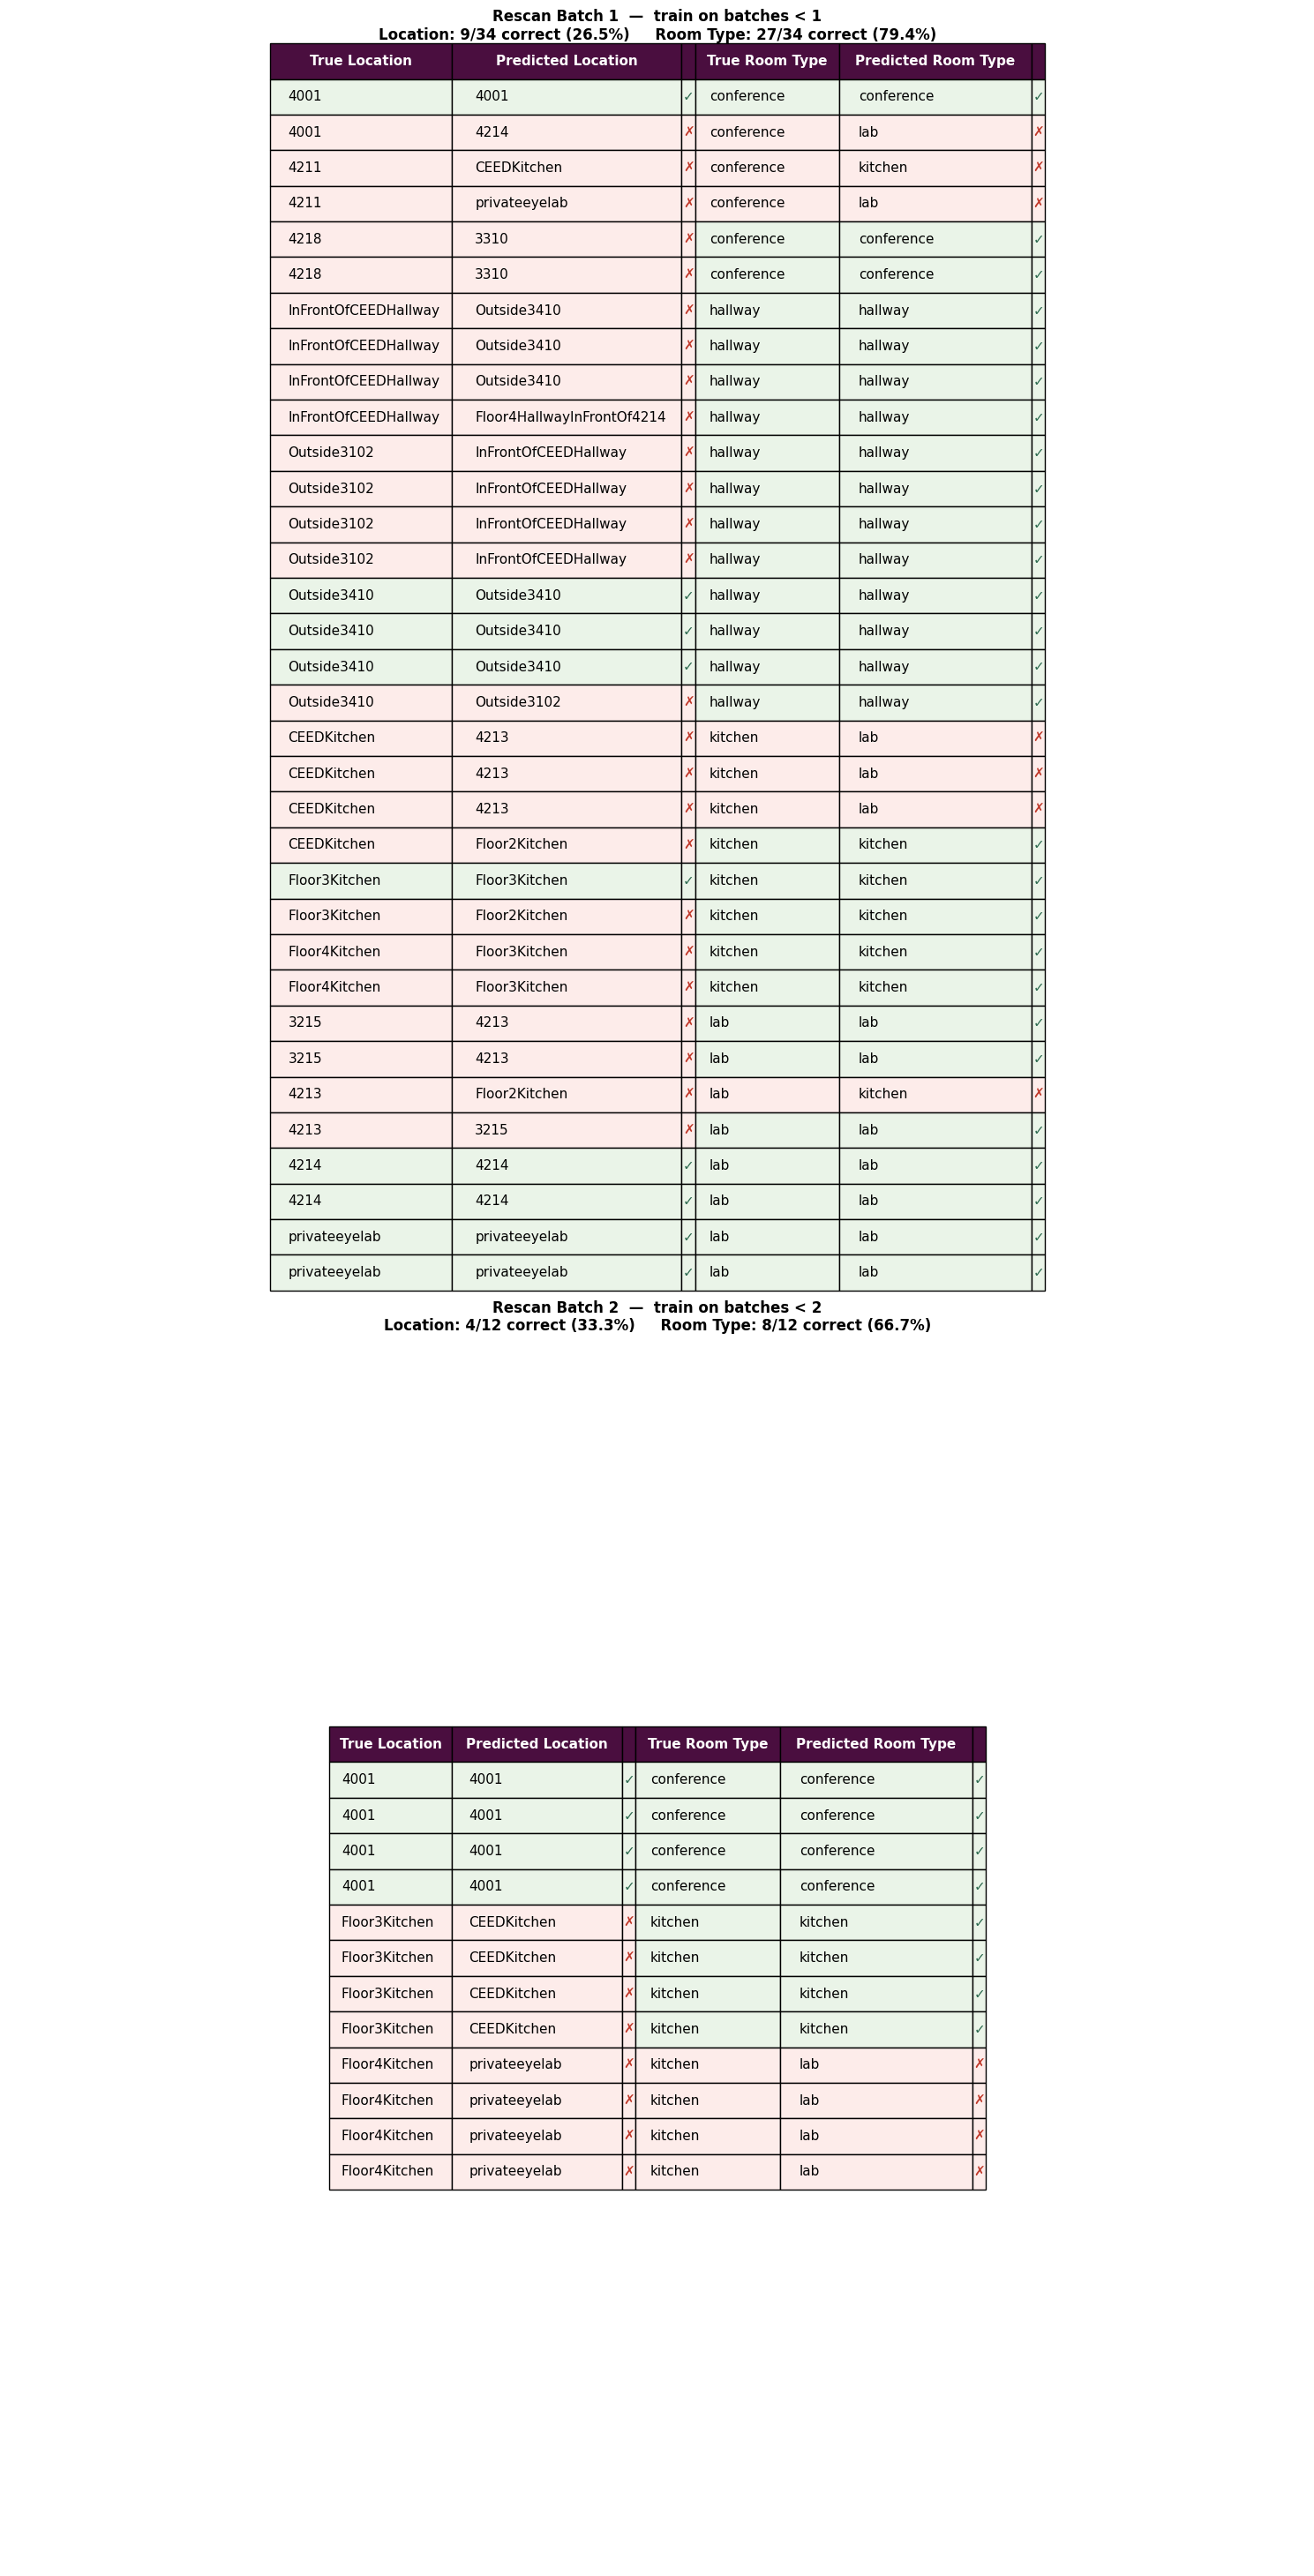

In [3]:
# ── Cell 3: Results Table ─────────────────────────────────────────────────────
GREEN_BG = "#eaf4e8"
RED_BG   = "#fdecea"
GREEN_FG = "#2d6a4f"
RED_FG   = "#c0392b"
HEADER   = "#4a0e3f"

test_batches = sorted(results_df["test_batch"].unique())

fig, axes = plt.subplots(
    len(test_batches), 1,
    figsize=(15, sum(
        len(results_df[results_df["test_batch"] == b]) * 0.55 + 2.0
        for b in test_batches
    ))
)
if len(test_batches) == 1:
    axes = [axes]

for ax, batch in zip(axes, test_batches):
    batch_df = results_df[results_df["test_batch"] == batch].reset_index(drop=True)
    ax.axis("off")

    cell_text = [
        [
            r["true_location"],
            r["pred_location"],
            "✓" if r["loc_correct"]  else "✗",
            r["true_room"],
            r["pred_room"],
            "✓" if r["room_correct"] else "✗",
        ]
        for _, r in batch_df.iterrows()
    ]

    table = ax.table(
        cellText=cell_text,
        colLabels=["True Location", "Predicted Location", "", "True Room Type", "Predicted Room Type", ""],
        loc="center",
        cellLoc="left",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.8)

    # Header
    for j in range(6):
        table[0, j].set_facecolor(HEADER)
        table[0, j].set_text_props(color="white", fontweight="bold")

    # Data rows
    for i, row in batch_df.iterrows():
        for j in range(3):
            table[i + 1, j].set_facecolor(GREEN_BG if row["loc_correct"] else RED_BG)
        table[i + 1, 2].set_text_props(
            color=GREEN_FG if row["loc_correct"] else RED_FG,
            fontweight="bold",
        )
        for j in range(3, 6):
            table[i + 1, j].set_facecolor(GREEN_BG if row["room_correct"] else RED_BG)
        table[i + 1, 5].set_text_props(
            color=GREEN_FG if row["room_correct"] else RED_FG,
            fontweight="bold",
        )

    table.auto_set_column_width([0, 1, 2, 3, 4, 5])

    loc_acc  = batch_df["loc_correct"].mean()
    room_acc = batch_df["room_correct"].mean()
    n        = len(batch_df)
    ax.set_title(
        f"Rescan Batch {batch}  —  train on batches < {batch}\n"
        f"Location: {batch_df['loc_correct'].sum()}/{n} correct ({loc_acc:.1%})     "
        f"Room Type: {batch_df['room_correct'].sum()}/{n} correct ({room_acc:.1%})",
        fontsize=12, fontweight="bold", pad=15,
    )

plt.tight_layout()
plt.show()

  Held out: 3211                           room=conference   acc=1.0000  (n=2)
  Held out: 3215                           room=lab          acc=0.6250  (n=8)
  Held out: 3310                           room=conference   acc=1.0000  (n=6)
  Held out: 4001                           room=conference   acc=0.2500  (n=12)
  Held out: 4211                           room=conference   acc=0.3750  (n=8)
  Held out: 4213                           room=lab          acc=0.2500  (n=8)
  Held out: 4214                           room=lab          acc=0.0000  (n=8)
  Held out: 4218                           room=conference   acc=0.2500  (n=8)
  Held out: 4307                           room=conference   acc=0.6667  (n=6)
  Held out: CEEDKitchen                    room=kitchen      acc=0.9000  (n=10)
  Held out: Floor2Kitchen                  room=kitchen      acc=0.6667  (n=6)
  Held out: Floor3HallwayNearWorkArea      room=hallway      acc=1.0000  (n=2)
  Held out: Floor3Kitchen                  room=ki

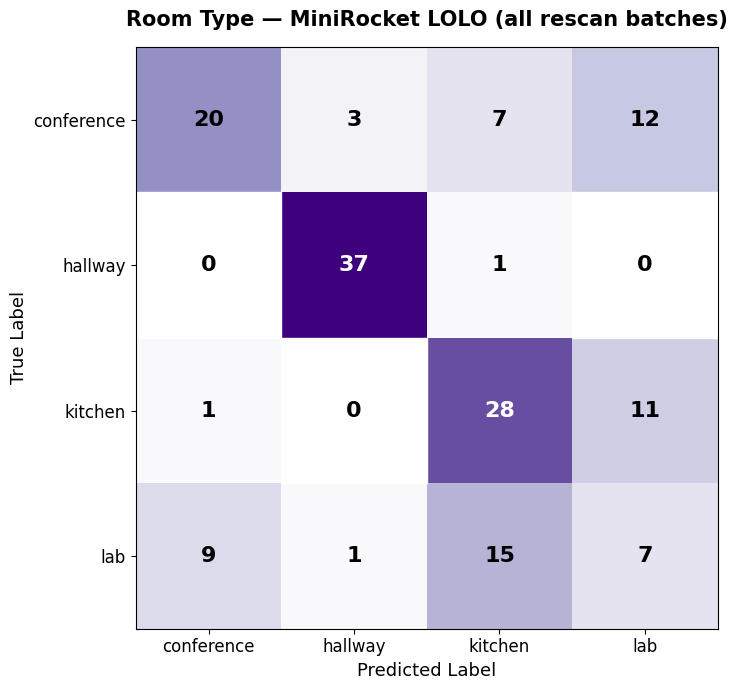

In [4]:
# ── Cell 4: MiniRocket LOLO — Room Type Classification (all rescan batches) ───
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

room_enc = LabelEncoder().fit(df["room_label"].unique())
groups   = np.array([
    loc for scan_id, group in df.groupby("scan_id")
    for loc in [group.iloc[0]["location"]]
])

# Build full scan array across all rescan batches
X_all, _, loc_all = build_scan_array(df)
y_all = room_enc.transform([loc_to_room[l] for l in loc_all])

logo = LeaveOneGroupOut()
y_true_all, y_pred_all, fold_results = [], [], []

for train_idx, test_idx in logo.split(X_all, y_all, groups):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]
    held_out   = groups[test_idx][0]

    clf = MiniRocketClassifier(random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    fold_results.append({
        "held_out":  held_out,
        "room_type": loc_to_room[held_out],
        "n_test":    len(y_te),
        "accuracy":  acc,
    })
    y_true_all.extend(y_te)
    y_pred_all.extend(y_pred)
    print(f"  Held out: {held_out:<30} room={loc_to_room[held_out]:<12} acc={acc:.4f}  (n={len(y_te)})")

results_df_lolo = pd.DataFrame(fold_results)
overall_acc = accuracy_score(y_true_all, y_pred_all)

print(f"\n{'='*60}")
print(f"LOLO mean accuracy (per-fold avg) : {results_df_lolo['accuracy'].mean():.4f} ± {results_df_lolo['accuracy'].std():.4f}")
print(f"LOLO overall accuracy (all scans) : {overall_acc:.4f}")
print(f"{'='*60}\n")

print("Per-room-type breakdown:")
print(results_df_lolo.groupby("room_type")["accuracy"].agg(["mean", "std", "count"]).round(4))

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=room_enc.classes_, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true_all, y_pred_all),
    display_labels=room_enc.classes_,
)
disp.plot(ax=ax, colorbar=False, cmap="Purples")

images = ax.get_images()
norm   = images[0].norm
cmap_  = images[0].get_cmap()
for i, row in enumerate(disp.text_):
    for j, text in enumerate(row):
        val = disp.confusion_matrix[i, j]
        if val == 0:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="white", zorder=2))
            text.set_color("black")
        else:
            r, g, b, _ = cmap_(norm(val))
            text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
        text.set_fontsize(16)
        text.set_fontweight("bold")
        text.set_zorder(3)

ax.set_title("Room Type — MiniRocket LOLO (all rescan batches)", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

  Held out: 3211                           room=conference   room_acc=1.0000  loc_acc=0.0000  (n=8)
  Held out: 3215                           room=lab          room_acc=0.6250  loc_acc=0.0000  (n=8)
  Held out: 3310                           room=conference   room_acc=0.8333  loc_acc=0.0000  (n=8)
  Held out: 4001                           room=conference   room_acc=0.0000  loc_acc=0.0000  (n=8)
  Held out: 4211                           room=conference   room_acc=0.1250  loc_acc=0.0000  (n=8)
  Held out: 4213                           room=lab          room_acc=0.5000  loc_acc=0.0000  (n=8)
  Held out: 4214                           room=lab          room_acc=0.1250  loc_acc=0.0000  (n=8)
  Held out: 4218                           room=conference   room_acc=0.1250  loc_acc=0.0000  (n=8)
  Held out: 4307                           room=conference   room_acc=0.5000  loc_acc=0.0000  (n=8)
  Held out: CEEDKitchen                    room=kitchen      room_acc=0.7000  loc_acc=0.0000  (n=8)


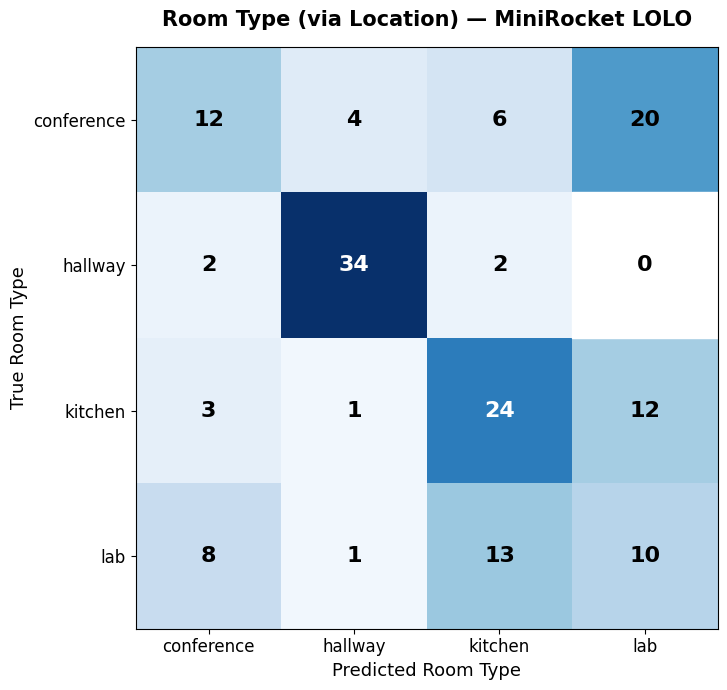

In [8]:
# ── Cell 5: MiniRocket LOLO — Location → Room Type (indirect) ────────────────
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

room_enc = LabelEncoder().fit(df["room_label"].unique())

# Build full scan array across all rescan batches
X_all, y_loc_all, loc_all = build_scan_array(df)
groups = np.array(loc_all)

logo = LeaveOneGroupOut()
y_true_room_all, y_pred_room_all, fold_results = [], [], []

for train_idx, test_idx in logo.split(X_all, y_loc_all, groups):
    X_tr, X_te   = X_all[train_idx], X_all[test_idx]
    y_tr          = y_loc_all[train_idx]
    held_out_loc  = groups[test_idx][0]
    true_room     = loc_to_room[held_out_loc]

    # Train on locations, predict location
    clf = MiniRocketClassifier(random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred_loc = clf.predict(X_te)

    # Map predicted locations → room types
    pred_locs  = loc_enc.inverse_transform(y_pred_loc)
    pred_rooms = [loc_to_room[l] for l in pred_locs]
    true_rooms = [true_room] * len(pred_rooms)

    # Encode room types for confusion matrix
    y_true_room = room_enc.transform(true_rooms)
    y_pred_room = room_enc.transform(pred_rooms)

    acc = accuracy_score(y_true_room, y_pred_room)
    fold_results.append({
        "held_out":       held_out_loc,
        "true_room":      true_room,
        "n_test":         len(y_te),
        "room_acc":       acc,
        "loc_acc":        accuracy_score(y_loc_all[test_idx], y_pred_loc),
    })
    y_true_room_all.extend(y_true_room)
    y_pred_room_all.extend(y_pred_room)

    print(f"  Held out: {held_out_loc:<30} room={true_room:<12} room_acc={acc:.4f}  loc_acc={fold_results[-1]['loc_acc']:.4f}  (n={len(y_te)})")

results_df_indirect = pd.DataFrame(fold_results)
overall_room_acc = accuracy_score(y_true_room_all, y_pred_room_all)
overall_loc_acc  = results_df_indirect["loc_acc"].mean()

print(f"\n{'='*60}")
print(f"LOLO room type accuracy (indirect) : {overall_room_acc:.4f}")
print(f"LOLO location accuracy (direct)    : {overall_loc_acc:.4f}")
print(f"{'='*60}\n")

print("Per-room-type breakdown:")
print(results_df_indirect.groupby("true_room")["room_acc"].agg(["mean", "std", "count"]).round(4))

print("\nClassification Report:")
print(classification_report(y_true_room_all, y_pred_room_all, target_names=room_enc.classes_, zero_division=0))

# ── 4x4 confusion matrix ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true_room_all, y_pred_room_all),
    display_labels=room_enc.classes_,
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")

images = ax.get_images()
norm   = images[0].norm
cmap_  = images[0].get_cmap()
for i, row in enumerate(disp.text_):
    for j, text in enumerate(row):
        val = disp.confusion_matrix[i, j]
        if val == 0:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="white", zorder=2))
            text.set_color("black")
        else:
            r, g, b, _ = cmap_(norm(val))
            text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
        text.set_fontsize(16)
        text.set_fontweight("bold")
        text.set_zorder(3)

ax.set_title("Room Type (via Location) — MiniRocket LOLO", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Room Type", fontsize=13)
ax.set_ylabel("True Room Type", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

Total scans      : 152
Unique group keys: 35
Groups:
group_key
3211__r0                          2
3215__r0                          6
3215__r1                          2
3310__r0                          6
4001__r0                          6
4001__r1                          2
4001__r2                          4
4211__r0                          6
4211__r1                          2
4213__r0                          6
4213__r1                          2
4214__r0                          6
4214__r1                          2
4218__r0                          6
4218__r1                          2
4307__r0                          6
CEEDKitchen__r0                   6
CEEDKitchen__r1                   4
Floor2Kitchen__r0                 6
Floor3HallwayNearWorkArea__r0     2
Floor3Kitchen__r0                 6
Floor3Kitchen__r1                 2
Floor3Kitchen__r2                 4
Floor4HallwayInFrontOf4214__r0    6
Floor4Kitchen__r0                 6
Floor4Kitchen__r1                 2
F

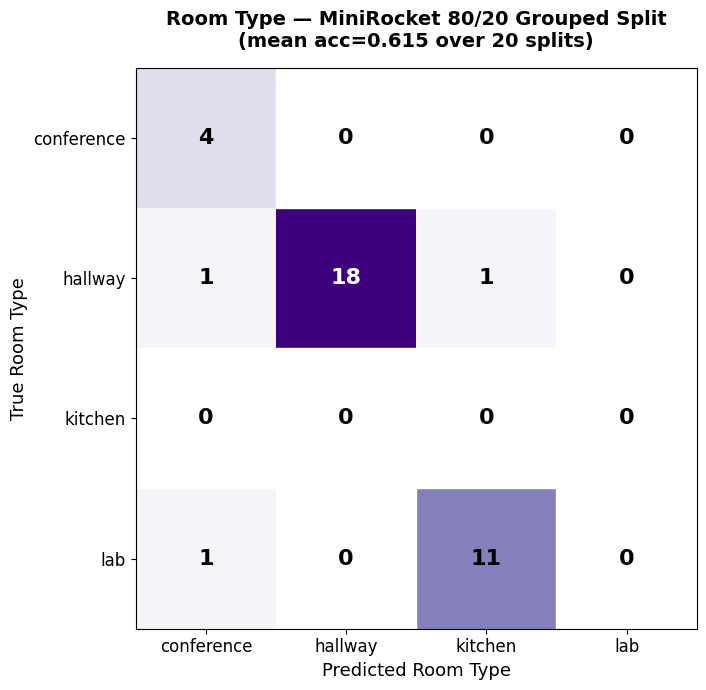

In [9]:
# ── Cell 6: MiniRocket — 80/20 Split (grouped by location + rescan_num) ───────
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Create group key: location + rescan_num combo
scan_meta = pd.DataFrame([
    {
        "scan_id":    scan_id,
        "location":   group.iloc[0]["location"],
        "room_label": group.iloc[0]["room_label"],
        "rescan_num": group.iloc[0]["rescan_num"],
    }
    for scan_id, group in df.groupby("scan_id")
])
scan_meta["group_key"] = scan_meta["location"] + "__r" + scan_meta["rescan_num"].astype(str)

X_all, y_loc_all, loc_all = build_scan_array(df)
y_room_all = room_enc.transform([loc_to_room[l] for l in loc_all])
group_keys = scan_meta["group_key"].values

print(f"Total scans      : {len(scan_meta)}")
print(f"Unique group keys: {scan_meta['group_key'].nunique()}")
print(f"Groups:\n{scan_meta.groupby('group_key')['scan_id'].count().to_string()}\n")

# ── Run multiple splits and average for stability ────────────────────────────
N_SPLITS  = 20
gss = GroupShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=42)

split_accs = []
y_true_final, y_pred_final = [], []

for split_idx, (train_idx, test_idx) in enumerate(gss.split(X_all, y_room_all, group_keys)):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_room_all[train_idx], y_room_all[test_idx]

    # Verify no group leakage
    train_groups = set(group_keys[train_idx])
    test_groups  = set(group_keys[test_idx])
    assert len(train_groups & test_groups) == 0, "Group leakage detected!"

    clf = MiniRocketClassifier(random_state=split_idx)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    split_accs.append(acc)

    # Keep last split for confusion matrix
    if split_idx == N_SPLITS - 1:
        y_true_final = y_te
        y_pred_final = y_pred

    print(f"  Split {split_idx+1:>2}  |  train={len(train_idx)} scans  test={len(test_idx)} scans  acc={acc:.4f}  |  test groups: {sorted(test_groups)}")

print(f"\n{'='*60}")
print(f"Mean accuracy over {N_SPLITS} splits: {np.mean(split_accs):.4f} ± {np.std(split_accs):.4f}")
print(f"Min: {np.min(split_accs):.4f}   Max: {np.max(split_accs):.4f}")
print(f"{'='*60}\n")

print("Classification Report (last split):")
print(classification_report(y_true_final, y_pred_final, target_names=room_enc.classes_, zero_division=0))

# ── Confusion matrix (last split) ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true_final, y_pred_final),
    display_labels=room_enc.classes_,
)
disp.plot(ax=ax, colorbar=False, cmap="Purples")

images = ax.get_images()
norm   = images[0].norm
cmap_  = images[0].get_cmap()
for i, row in enumerate(disp.text_):
    for j, text in enumerate(row):
        val = disp.confusion_matrix[i, j]
        if val == 0:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="white", zorder=2))
            text.set_color("black")
        else:
            r, g, b, _ = cmap_(norm(val))
            text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
        text.set_fontsize(16)
        text.set_fontweight("bold")
        text.set_zorder(3)

ax.set_title(f"Room Type — MiniRocket 80/20 Grouped Split\n(mean acc={np.mean(split_accs):.3f} over {N_SPLITS} splits)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Room Type", fontsize=13)
ax.set_ylabel("True Room Type", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

Total scans       : 152
Unique group keys : 35

  Held out: 3211__r0                                 room=conference   acc=1.0000  (n=2)
  Held out: 3215__r0                                 room=lab          acc=0.5000  (n=6)
  Held out: 3215__r1                                 room=lab          acc=0.5000  (n=2)
  Held out: 3310__r0                                 room=conference   acc=1.0000  (n=6)
  Held out: 4001__r0                                 room=conference   acc=1.0000  (n=6)
  Held out: 4001__r1                                 room=conference   acc=0.5000  (n=2)
  Held out: 4001__r2                                 room=conference   acc=1.0000  (n=4)
  Held out: 4211__r0                                 room=conference   acc=0.5000  (n=6)
  Held out: 4211__r1                                 room=conference   acc=0.0000  (n=2)
  Held out: 4213__r0                                 room=lab          acc=0.1667  (n=6)
  Held out: 4213__r1                                 room=lab 

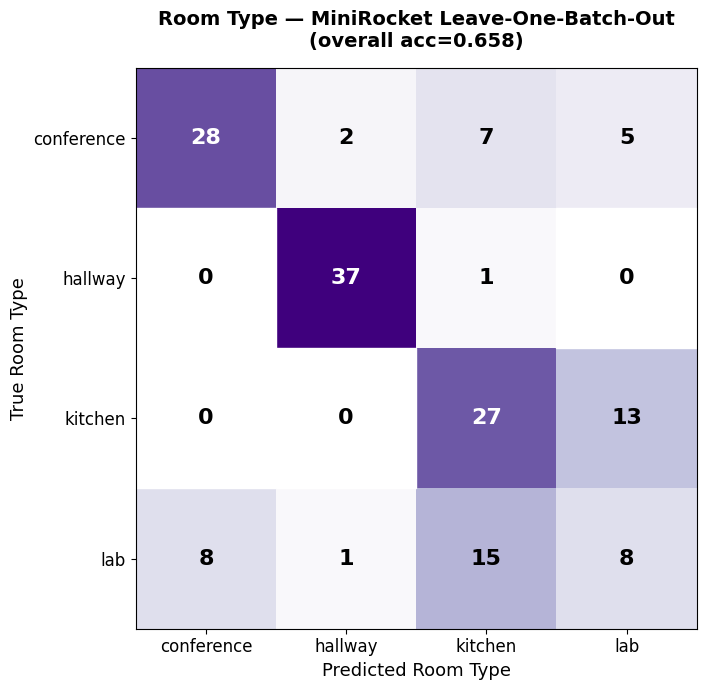

In [10]:
# ── Cell 6: MiniRocket — Leave-One-Batch-Out (location + rescan_num) ──────────
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Build scan-level metadata with group key
scan_meta = pd.DataFrame([
    {
        "scan_id":    scan_id,
        "location":   group.iloc[0]["location"],
        "room_label": group.iloc[0]["room_label"],
        "rescan_num": int(group.iloc[0]["rescan_num"]),
    }
    for scan_id, group in df.groupby("scan_id")
])
scan_meta["group_key"] = scan_meta["location"] + "__r" + scan_meta["rescan_num"].astype(str)

X_all, _, loc_all = build_scan_array(df)
y_room_all = room_enc.transform([loc_to_room[l] for l in loc_all])
group_keys = scan_meta["group_key"].values

print(f"Total scans       : {len(scan_meta)}")
print(f"Unique group keys : {scan_meta['group_key'].nunique()}")
print()

logo = LeaveOneGroupOut()
y_true_all, y_pred_all, fold_results = [], [], []

for train_idx, test_idx in logo.split(X_all, y_room_all, group_keys):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_room_all[train_idx], y_room_all[test_idx]
    held_out   = group_keys[test_idx][0]
    held_loc   = scan_meta.loc[test_idx[0], "location"]
    held_room  = loc_to_room[held_loc]
    held_batch = scan_meta.loc[test_idx[0], "rescan_num"]

    clf = MiniRocketClassifier(random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    fold_results.append({
        "group_key":  held_out,
        "location":   held_loc,
        "room_type":  held_room,
        "rescan_num": held_batch,
        "n_test":     len(y_te),
        "accuracy":   acc,
    })
    y_true_all.extend(y_te)
    y_pred_all.extend(y_pred)

    print(f"  Held out: {held_out:<40} room={held_room:<12} acc={acc:.4f}  (n={len(y_te)})")

results_df_lobo = pd.DataFrame(fold_results)
overall_acc = accuracy_score(y_true_all, y_pred_all)

print(f"\n{'='*60}")
print(f"LOBO mean accuracy (per-fold avg) : {results_df_lobo['accuracy'].mean():.4f} ± {results_df_lobo['accuracy'].std():.4f}")
print(f"LOBO overall accuracy (all scans) : {overall_acc:.4f}")
print(f"{'='*60}\n")

print("Per-room-type breakdown:")
print(results_df_lobo.groupby("room_type")["accuracy"].agg(["mean", "std", "count"]).round(4))

print("\nPer-rescan-batch breakdown:")
print(results_df_lobo.groupby("rescan_num")["accuracy"].agg(["mean", "std", "count"]).round(4))

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=room_enc.classes_, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true_all, y_pred_all),
    display_labels=room_enc.classes_,
)
disp.plot(ax=ax, colorbar=False, cmap="Purples")

images = ax.get_images()
norm   = images[0].norm
cmap_  = images[0].get_cmap()
for i, row in enumerate(disp.text_):
    for j, text in enumerate(row):
        val = disp.confusion_matrix[i, j]
        if val == 0:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="white", zorder=2))
            text.set_color("black")
        else:
            r, g, b, _ = cmap_(norm(val))
            text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
        text.set_fontsize(16)
        text.set_fontweight("bold")
        text.set_zorder(3)

ax.set_title(f"Room Type — MiniRocket Leave-One-Batch-Out\n(overall acc={overall_acc:.3f})",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Room Type", fontsize=13)
ax.set_ylabel("True Room Type", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

Locations with rescan data: ['3215', '4001', '4211', '4213', '4214', '4218', 'CEEDKitchen', 'Floor3Kitchen', 'Floor4Kitchen', 'InFrontOfCEEDHallway', 'Outside3102', 'Outside3410', 'privateeyelab']

  Held out: 3215__r1                                 room=lab          acc=0.5000  (n=2)
  Held out: 4001__r1                                 room=conference   acc=0.5000  (n=2)
  Held out: 4001__r2                                 room=conference   acc=1.0000  (n=4)
  Held out: 4211__r1                                 room=conference   acc=0.0000  (n=2)
  Held out: 4213__r1                                 room=lab          acc=0.5000  (n=2)
  Held out: 4214__r1                                 room=lab          acc=0.0000  (n=2)
  Held out: 4218__r1                                 room=conference   acc=1.0000  (n=2)
  Held out: CEEDKitchen__r1                          room=kitchen      acc=0.5000  (n=4)
  Held out: Floor3Kitchen__r1                        room=kitchen      acc=0.5000  (n=2)
 

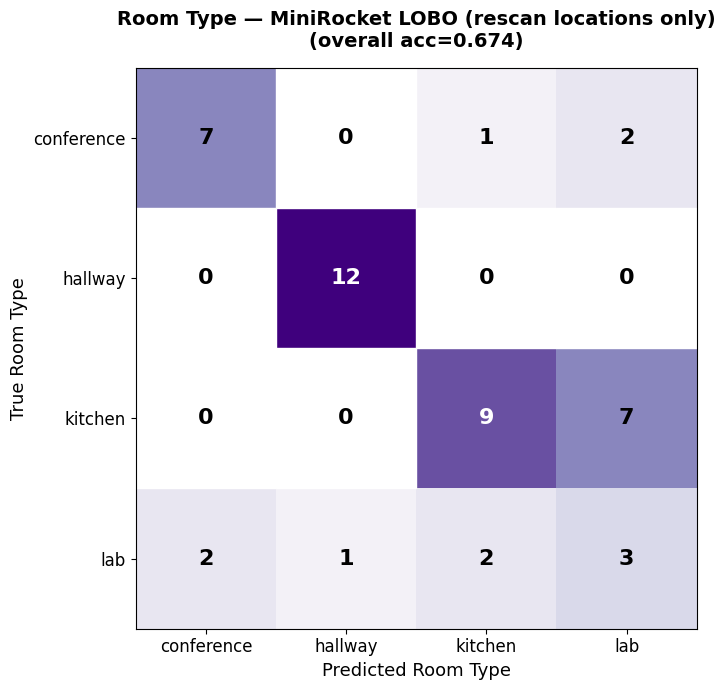

In [11]:
# ── Cell 7: MiniRocket LOBO — Test only locations with rescan data ─────────────
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Locations that have at least one rescan=True scan
rescan_locations = set(df[df["rescan"] == True]["location"].unique())
print(f"Locations with rescan data: {sorted(rescan_locations)}\n")

# Build scan-level metadata with group key
scan_meta = pd.DataFrame([
    {
        "scan_id":    scan_id,
        "location":   group.iloc[0]["location"],
        "room_label": group.iloc[0]["room_label"],
        "rescan_num": int(group.iloc[0]["rescan_num"]),
        "rescan":     bool(group.iloc[0]["rescan"]),
    }
    for scan_id, group in df.groupby("scan_id")
])
scan_meta["group_key"] = scan_meta["location"] + "__r" + scan_meta["rescan_num"].astype(str)

X_all, _, loc_all = build_scan_array(df)
y_room_all = room_enc.transform([loc_to_room[l] for l in loc_all])
group_keys = scan_meta["group_key"].values

logo = LeaveOneGroupOut()
y_true_all, y_pred_all, fold_results = [], [], []

for train_idx, test_idx in logo.split(X_all, y_room_all, group_keys):
    held_out  = group_keys[test_idx][0]
    held_loc  = scan_meta.loc[test_idx[0], "location"]
    held_room = loc_to_room[held_loc]
    held_batch = scan_meta.loc[test_idx[0], "rescan_num"]
    is_rescan  = scan_meta.loc[test_idx[0], "rescan"]

    # Only evaluate folds where the held-out batch is a rescan (rescan=True)
    if not is_rescan:
        continue

    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_room_all[train_idx], y_room_all[test_idx]

    clf = MiniRocketClassifier(random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    fold_results.append({
        "group_key":  held_out,
        "location":   held_loc,
        "room_type":  held_room,
        "rescan_num": held_batch,
        "n_test":     len(y_te),
        "accuracy":   acc,
    })
    y_true_all.extend(y_te)
    y_pred_all.extend(y_pred)

    print(f"  Held out: {held_out:<40} room={held_room:<12} acc={acc:.4f}  (n={len(y_te)})")

results_df_rescan = pd.DataFrame(fold_results)
overall_acc = accuracy_score(y_true_all, y_pred_all)

print(f"\n{'='*60}")
print(f"LOBO mean accuracy (per-fold avg) : {results_df_rescan['accuracy'].mean():.4f} ± {results_df_rescan['accuracy'].std():.4f}")
print(f"LOBO overall accuracy (all scans) : {overall_acc:.4f}")
print(f"{'='*60}\n")

print("Per-room-type breakdown:")
print(results_df_rescan.groupby("room_type")["accuracy"].agg(["mean", "std", "count"]).round(4))

print("\nPer-rescan-batch breakdown:")
print(results_df_rescan.groupby("rescan_num")["accuracy"].agg(["mean", "std", "count"]).round(4))

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=room_enc.classes_, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true_all, y_pred_all),
    display_labels=room_enc.classes_,
)
disp.plot(ax=ax, colorbar=False, cmap="Purples")

images = ax.get_images()
norm   = images[0].norm
cmap_  = images[0].get_cmap()
for i, row in enumerate(disp.text_):
    for j, text in enumerate(row):
        val = disp.confusion_matrix[i, j]
        if val == 0:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="white", zorder=2))
            text.set_color("black")
        else:
            r, g, b, _ = cmap_(norm(val))
            text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
        text.set_fontsize(16)
        text.set_fontweight("bold")
        text.set_zorder(3)

ax.set_title(f"Room Type — MiniRocket LOBO (rescan locations only)\n(overall acc={overall_acc:.3f})",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Room Type", fontsize=13)
ax.set_ylabel("True Room Type", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

In [12]:
# ── Cell 8: MiniRocket — Reproduce 79.4% (train batch 0, test batch 1) ────────
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.metrics import accuracy_score

train_df = df[df["rescan_num"] < 1]
test_df  = df[(df["rescan"] == True) & (df["rescan_num"] == 1)]

print(f"Train scans : {train_df['scan_id'].nunique()}  across {train_df['location'].nunique()} locations")
print(f"Test scans  : {test_df['scan_id'].nunique()}   across {sorted(test_df['location'].unique())}\n")

X_train, y_train, _         = build_scan_array(train_df)
X_test,  y_test,  test_locs = build_scan_array(test_df)

clf = MiniRocketClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred_loc = clf.predict(X_test)

pred_locs  = loc_enc.inverse_transform(y_pred_loc)
true_locs  = loc_enc.inverse_transform(y_test)
pred_rooms = [loc_to_room[l] for l in pred_locs]
true_rooms = [loc_to_room[l] for l in true_locs]

room_acc = sum(t == p for t, p in zip(true_rooms, pred_rooms)) / len(true_rooms)
loc_acc  = sum(t == p for t, p in zip(true_locs,  pred_locs))  / len(true_locs)

print(f"{'True Location':<30} {'Predicted Location':<30} {'Loc':>4}  {'True Room':<12} {'Pred Room':<12} {'Room':>5}")
print("-" * 100)
for tl, pl, tr, pr in zip(true_locs, pred_locs, true_rooms, pred_rooms):
    print(f"{tl:<30} {pl:<30} {'✓' if tl==pl else '✗':>4}  {tr:<12} {pr:<12} {'✓' if tr==pr else '✗':>5}")

print(f"\nLocation accuracy : {loc_acc:.1%}  ({sum(t==p for t,p in zip(true_locs, pred_locs))}/{len(true_locs)})")
print(f"Room type accuracy: {room_acc:.1%}  ({sum(t==p for t,p in zip(true_rooms, pred_rooms))}/{len(true_rooms)})")

Train scans : 106  across 19 locations
Test scans  : 34   across ['3215', '4001', '4211', '4213', '4214', '4218', 'CEEDKitchen', 'Floor3Kitchen', 'Floor4Kitchen', 'InFrontOfCEEDHallway', 'Outside3102', 'Outside3410', 'privateeyelab']

True Location                  Predicted Location              Loc  True Room    Pred Room     Room
----------------------------------------------------------------------------------------------------
4001                           4001                              ✓  conference   conference       ✓
4001                           4214                              ✗  conference   lab              ✗
4211                           CEEDKitchen                       ✗  conference   kitchen          ✗
4211                           privateeyelab                     ✗  conference   lab              ✗
4218                           3310                              ✗  conference   conference       ✓
4218                           3310                             

Train scans : 106  across 19 locations
Test scans  : 34   across ['3215', '4001', '4211', '4213', '4214', '4218', 'CEEDKitchen', 'Floor3Kitchen', 'Floor4Kitchen', 'InFrontOfCEEDHallway', 'Outside3102', 'Outside3410', 'privateeyelab']

True Location                  True Room    Predicted Room     
-----------------------------------------------------------------
4001                           conference   conference      ✓
4001                           conference   lab             ✗
4211                           conference   kitchen         ✗
4211                           conference   lab             ✗
4218                           conference   conference      ✓
4218                           conference   conference      ✓
InFrontOfCEEDHallway           hallway      hallway         ✓
InFrontOfCEEDHallway           hallway      hallway         ✓
InFrontOfCEEDHallway           hallway      hallway         ✓
InFrontOfCEEDHallway           hallway      hallway         ✓
Outside3102    

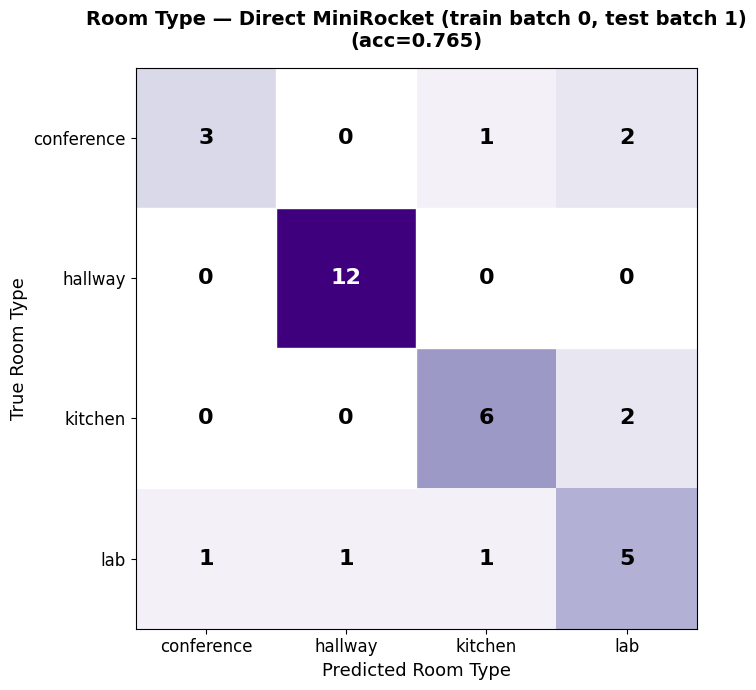

In [13]:
# ── Cell 9: MiniRocket — Direct Room Type (train batch 0, test batch 1) ───────
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

train_df = df[df["rescan_num"] < 1]
test_df  = df[(df["rescan"] == True) & (df["rescan_num"] == 1)]

print(f"Train scans : {train_df['scan_id'].nunique()}  across {train_df['location'].nunique()} locations")
print(f"Test scans  : {test_df['scan_id'].nunique()}   across {sorted(test_df['location'].unique())}\n")

X_train, _, train_locs = build_scan_array(train_df)
X_test,  _, test_locs  = build_scan_array(test_df)

y_train = room_enc.transform([loc_to_room[l] for l in train_locs])
y_test  = room_enc.transform([loc_to_room[l] for l in test_locs])

clf = MiniRocketClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

pred_rooms = room_enc.inverse_transform(y_pred)
true_rooms = room_enc.inverse_transform(y_test)

print(f"{'True Location':<30} {'True Room':<12} {'Predicted Room':<12} {'':>4}")
print("-" * 65)
for loc, tr, pr in zip(test_locs, true_rooms, pred_rooms):
    print(f"{loc:<30} {tr:<12} {pr:<12} {'✓' if tr==pr else '✗':>4}")

acc = accuracy_score(y_test, y_pred)
print(f"\nRoom type accuracy: {acc:.1%}  ({sum(y_test==y_pred)}/{len(y_test)})")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=room_enc.classes_, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=room_enc.classes_,
)
disp.plot(ax=ax, colorbar=False, cmap="Purples")

images = ax.get_images()
norm   = images[0].norm
cmap_  = images[0].get_cmap()
for i, row in enumerate(disp.text_):
    for j, text in enumerate(row):
        val = disp.confusion_matrix[i, j]
        if val == 0:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="white", zorder=2))
            text.set_color("black")
        else:
            r, g, b, _ = cmap_(norm(val))
            text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
        text.set_fontsize(16)
        text.set_fontweight("bold")
        text.set_zorder(3)

ax.set_title(f"Room Type — Direct MiniRocket (train batch 0, test batch 1)\n(acc={acc:.3f})",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Room Type", fontsize=13)
ax.set_ylabel("True Room Type", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

Baseline accuracy: 0.7647

  GpuUtil              mean drop=+0.0088  std=0.0296
  CpuUtil              mean drop=-0.0000  std=0.0228
  FrameTimeStdDev      mean drop=-0.0294  std=0.0294
  WorstFrameMs         mean drop=+0.0324  std=0.0464
  MainThreadMs         mean drop=-0.0118  std=0.0300
  TotalUsedMem         mean drop=+0.5029  std=0.0549
  CpuClockFreq         mean drop=+0.0000  std=0.0000

=== CHANNEL IMPORTANCE (sorted) ===
        channel     mean_drop  std_drop  min_drop  max_drop
   TotalUsedMem  5.029412e-01  0.054946  0.382353  0.558824
   WorstFrameMs  3.235294e-02  0.046411 -0.029412  0.117647
        GpuUtil  8.823529e-03  0.029558 -0.029412  0.058824
   CpuClockFreq  0.000000e+00  0.000000  0.000000  0.000000
        CpuUtil -3.330669e-17  0.022782 -0.029412  0.029412
   MainThreadMs -1.176471e-02  0.029994 -0.058824  0.029412
FrameTimeStdDev -2.941176e-02  0.029412 -0.058824  0.029412


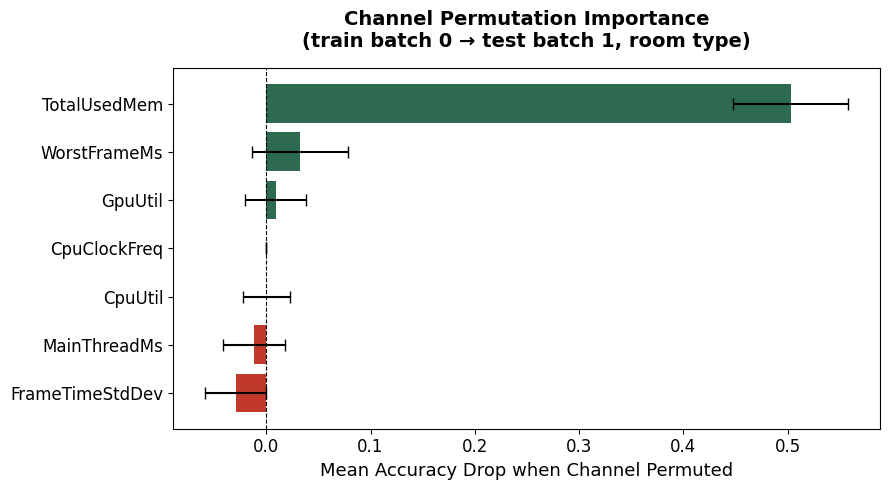


Saved permutation_importance_79pct_model.csv


In [14]:
# ── Cell 10: Permutation Importance on 79.4% Model ───────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.metrics import accuracy_score

# Rebuild the exact train/test split from Cell 8
train_df = df[df["rescan_num"] < 1]
test_df  = df[(df["rescan"] == True) & (df["rescan_num"] == 1)]

X_train, y_train, _         = build_scan_array(train_df)
X_test,  y_test,  test_locs = build_scan_array(test_df)

# Remap to room type labels (the 79.4% setup)
y_train_room = room_enc.transform([loc_to_room[l] for l in
                                   [df[df["scan_id"]==sid].iloc[0]["location"]
                                    for sid in train_df["scan_id"].unique()]])

# Simpler: rebuild directly
_, _, train_locs = build_scan_array(train_df)
y_train_room = room_enc.transform([loc_to_room[l] for l in train_locs])
y_test_room  = room_enc.transform([loc_to_room[l] for l in test_locs])

clf = MiniRocketClassifier(random_state=42)
clf.fit(X_train, y_train_room)

baseline_acc = accuracy_score(y_test_room, clf.predict(X_test))
print(f"Baseline accuracy: {baseline_acc:.4f}\n")

# ── Permute each channel and measure accuracy drop ───────────────────────────
N_REPEATS = 10   # repeat each permutation for stable estimates
rng = np.random.default_rng(42)

importance_rows = []
for ch_idx, ch_name in enumerate(CHANNELS):
    drop_scores = []
    for _ in range(N_REPEATS):
        X_permuted = X_test.copy()
        # Shuffle this channel across all scans
        perm = rng.permutation(X_permuted.shape[0])
        X_permuted[:, ch_idx, :] = X_permuted[perm, ch_idx, :]
        acc_permuted = accuracy_score(y_test_room, clf.predict(X_permuted))
        drop_scores.append(baseline_acc - acc_permuted)
    importance_rows.append({
        "channel":       ch_name,
        "mean_drop":     np.mean(drop_scores),
        "std_drop":      np.std(drop_scores),
        "min_drop":      np.min(drop_scores),
        "max_drop":      np.max(drop_scores),
    })
    print(f"  {ch_name:<20} mean drop={np.mean(drop_scores):+.4f}  std={np.std(drop_scores):.4f}")

importance_df = pd.DataFrame(importance_rows).sort_values("mean_drop", ascending=False).reset_index(drop=True)

print(f"\n=== CHANNEL IMPORTANCE (sorted) ===")
print(importance_df.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2d6a4f" if d > 0 else "#c0392b" for d in importance_df["mean_drop"]]
ax.barh(
    importance_df["channel"][::-1],
    importance_df["mean_drop"][::-1],
    xerr=importance_df["std_drop"][::-1],
    color=colors[::-1],
    capsize=4,
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean Accuracy Drop when Channel Permuted", fontsize=13)
ax.set_title("Channel Permutation Importance\n(train batch 0 → test batch 1, room type)", 
             fontsize=14, fontweight="bold", pad=15)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

importance_df.to_csv("permutation_importance_79pct_model.csv", index=False)
print("\nSaved permutation_importance_79pct_model.csv")

Channels used: ['TotalUsedMem', 'WorstFrameMs', 'GpuUtil']
Train scans  : 106  |  Test scans: 34

True Location                  True Room    Predicted Room     
-----------------------------------------------------------------
4001                           conference   conference      ✓
4001                           conference   conference      ✓
4211                           conference   kitchen         ✗
4211                           conference   lab             ✗
4218                           conference   conference      ✓
4218                           conference   conference      ✓
InFrontOfCEEDHallway           hallway      hallway         ✓
InFrontOfCEEDHallway           hallway      hallway         ✓
InFrontOfCEEDHallway           hallway      hallway         ✓
InFrontOfCEEDHallway           hallway      hallway         ✓
Outside3102                    hallway      hallway         ✓
Outside3102                    hallway      hallway         ✓
Outside3102                 

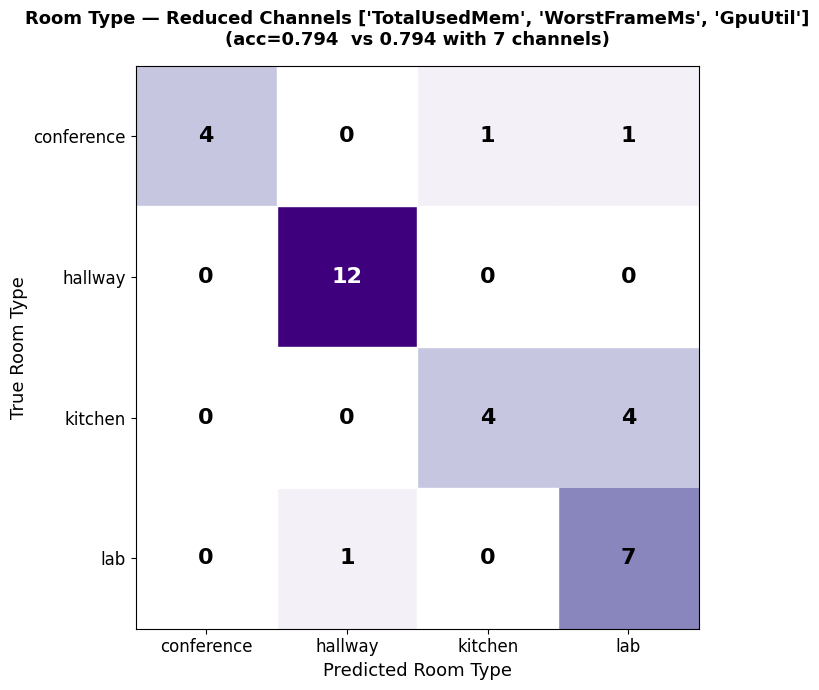

In [15]:
# ── Cell 11: MiniRocket — Reduced Channel Set ─────────────────────────────────
from aeon.classification.convolution_based import MiniRocketClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

CHANNELS_REDUCED = ["TotalUsedMem", "WorstFrameMs", "GpuUtil"]

def build_scan_array_reduced(data: pd.DataFrame, channels: list):
    records = []
    for scan_id, group in data.groupby("scan_id"):
        group = group.sort_values("Timestamp").iloc[:SERIES_LEN]
        meta  = group.iloc[0]
        records.append({
            "location": meta["location"],
            "ts":       group[channels].values.T,
        })
    X    = np.stack([r["ts"] for r in records])
    y    = loc_enc.transform([r["location"] for r in records])
    locs = [r["location"] for r in records]
    return X, y, locs

train_df = df[df["rescan_num"] < 1]
test_df  = df[(df["rescan"] == True) & (df["rescan_num"] == 1)]

X_train, _, train_locs = build_scan_array_reduced(train_df, CHANNELS_REDUCED)
X_test,  _, test_locs  = build_scan_array_reduced(test_df,  CHANNELS_REDUCED)

y_train = room_enc.transform([loc_to_room[l] for l in train_locs])
y_test  = room_enc.transform([loc_to_room[l] for l in test_locs])

clf = MiniRocketClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

pred_rooms = room_enc.inverse_transform(y_pred)
true_rooms = room_enc.inverse_transform(y_test)

print(f"Channels used: {CHANNELS_REDUCED}")
print(f"Train scans  : {len(X_train)}  |  Test scans: {len(X_test)}\n")

print(f"{'True Location':<30} {'True Room':<12} {'Predicted Room':<12} {'':>4}")
print("-" * 65)
for loc, tr, pr in zip(test_locs, true_rooms, pred_rooms):
    print(f"{loc:<30} {tr:<12} {pr:<12} {'✓' if tr==pr else '✗':>4}")

acc = accuracy_score(y_test, y_pred)
print(f"\nRoom type accuracy : {acc:.1%}  ({sum(y_test==y_pred)}/{len(y_test)})")
print(f"Previous (7 ch)    : 79.4%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=room_enc.classes_, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=room_enc.classes_,
)
disp.plot(ax=ax, colorbar=False, cmap="Purples")

images = ax.get_images()
norm   = images[0].norm
cmap_  = images[0].get_cmap()
for i, row in enumerate(disp.text_):
    for j, text in enumerate(row):
        val = disp.confusion_matrix[i, j]
        if val == 0:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="white", zorder=2))
            text.set_color("black")
        else:
            r, g, b, _ = cmap_(norm(val))
            text.set_color("white" if 0.299*r + 0.587*g + 0.114*b < 0.5 else "black")
        text.set_fontsize(16)
        text.set_fontweight("bold")
        text.set_zorder(3)

ax.set_title(f"Room Type — Reduced Channels {CHANNELS_REDUCED}\n(acc={acc:.3f}  vs 0.794 with 7 channels)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Room Type", fontsize=13)
ax.set_ylabel("True Room Type", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()